In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('focused_synthetic_loan_data.csv')

In [3]:
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,26032,467,Employed,Associate,24,17499,36,Divorced,...,2169.333333,0.704786,7,28301,0.268999,0.258727,703.859114,0.592283,0,52.0
1,2018-01-02,38,47162,552,Employed,High School,16,27728,60,Single,...,3930.166667,0.912653,8,1480,0.256728,0.242414,801.568058,0.296824,0,55.0
2,2018-01-03,47,26925,548,Self-Employed,Doctorate,26,14069,48,Married,...,2243.750000,0.680266,5,49697,0.235069,0.246830,464.003387,0.461283,0,59.0
3,2018-01-04,58,51278,583,Employed,Bachelor,36,40059,36,Single,...,4273.166667,0.881174,6,4204,0.233559,0.249076,1590.782097,0.456753,0,52.0
4,2018-01-05,37,179937,625,Employed,Bachelor,18,34774,48,Single,...,14994.750000,0.894550,4,39421,0.217274,0.260729,1173.911908,0.125038,1,40.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             2000 non-null   object 
 1   Age                         2000 non-null   int64  
 2   AnnualIncome                2000 non-null   int64  
 3   CreditScore                 2000 non-null   int64  
 4   EmploymentStatus            2000 non-null   object 
 5   EducationLevel              2000 non-null   object 
 6   Experience                  2000 non-null   int64  
 7   LoanAmount                  2000 non-null   int64  
 8   LoanDuration                2000 non-null   int64  
 9   MaritalStatus               2000 non-null   object 
 10  NumberOfDependents          2000 non-null   int64  
 11  HomeOwnershipStatus         2000 non-null   object 
 12  MonthlyDebtPayments         2000 non-null   int64  
 13  CreditCardUtilizationRate   2000 

In [5]:
df.drop(['ApplicationDate','EmploymentStatus','EducationLevel','MaritalStatus','HomeOwnershipStatus','LoanPurpose'],axis=1, inplace=True)

In [6]:
df.isnull().sum()

Age                           0
AnnualIncome                  0
CreditScore                   0
Experience                    0
LoanAmount                    0
LoanDuration                  0
NumberOfDependents            0
MonthlyDebtPayments           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
DebtToIncomeRatio             0
BankruptcyHistory             0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
TotalAssets                   0
TotalLiabilities              0
MonthlyIncome                 0
UtilityBillsPaymentHistory    0
JobTenure                     0
NetWorth                      0
BaseInterestRate              0
InterestRate                  0
MonthlyLoanPayment            0
TotalDebtToIncomeRatio        0
LoanApproved                  0
RiskScore                     0
dtype: int64

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2000.0,40.183000,11.526532,18.000000,32.000000,40.000000,48.000000,8.000000e+01
AnnualIncome,2000.0,58896.244500,41232.615305,15000.000000,30501.750000,47513.500000,74464.500000,3.000000e+05
CreditScore,2000.0,572.317500,50.301539,386.000000,541.000000,581.000000,609.000000,6.970000e+02
Experience,2000.0,17.931000,11.316062,0.000000,9.750000,17.000000,26.000000,5.800000e+01
LoanAmount,2000.0,24990.177500,13658.862298,3202.000000,15659.750000,21958.000000,31164.500000,1.581280e+05
LoanDuration,2000.0,52.932000,24.271834,12.000000,36.000000,48.000000,60.000000,1.200000e+02
NumberOfDependents,2000.0,1.549000,1.422888,0.000000,0.000000,1.000000,3.000000,5.000000e+00
MonthlyDebtPayments,2000.0,449.158500,244.976709,71.000000,276.750000,394.500000,559.000000,2.555000e+03
CreditCardUtilizationRate,2000.0,0.282750,0.156970,0.006882,0.159677,0.263912,0.391524,8.121706e-01
NumberOfOpenCreditLines,2000.0,2.968000,1.770182,0.000000,2.000000,3.000000,4.000000,1.000000e+01


In [8]:
X = df.drop(['RiskScore'],axis=1)
y = df['RiskScore']

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

<Axes: >

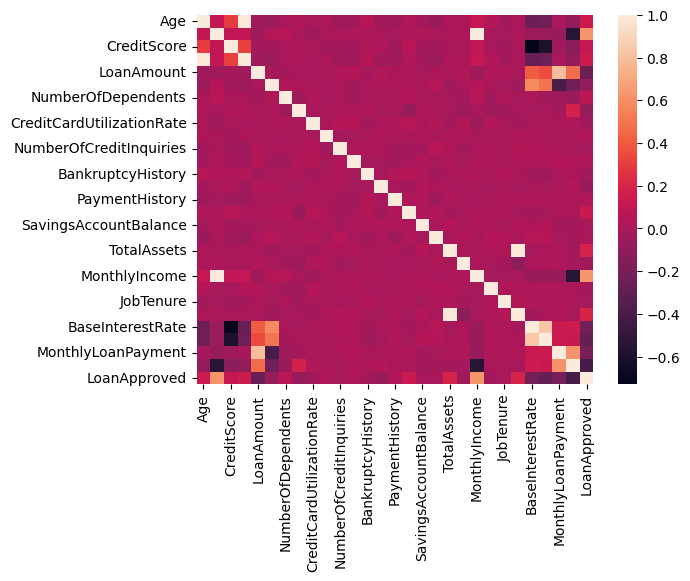

In [10]:
sns.heatmap(X_train.corr())

In [11]:
def correlation_for_dropping(df, threshold):
    columns_to_drop = set()
    corr = df.corr()
    for i in range(len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i, j]) > threshold:
                columns_to_drop.add(corr.columns[i])
    return columns_to_drop

In [12]:
columnsToDrop = correlation_for_dropping(X_train,0.80)
columnsToDrop

{'Experience', 'InterestRate', 'MonthlyIncome', 'NetWorth'}

In [13]:
X_train.drop(columnsToDrop,axis=1,inplace=True)

In [14]:
X_test.drop(columnsToDrop,axis=1,inplace=True)

In [15]:
X_train.columns

Index(['Age', 'AnnualIncome', 'CreditScore', 'LoanAmount', 'LoanDuration',
       'NumberOfDependents', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
       'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
       'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
       'TotalLiabilities', 'UtilityBillsPaymentHistory', 'JobTenure',
       'BaseInterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio',
       'LoanApproved'],
      dtype='object')

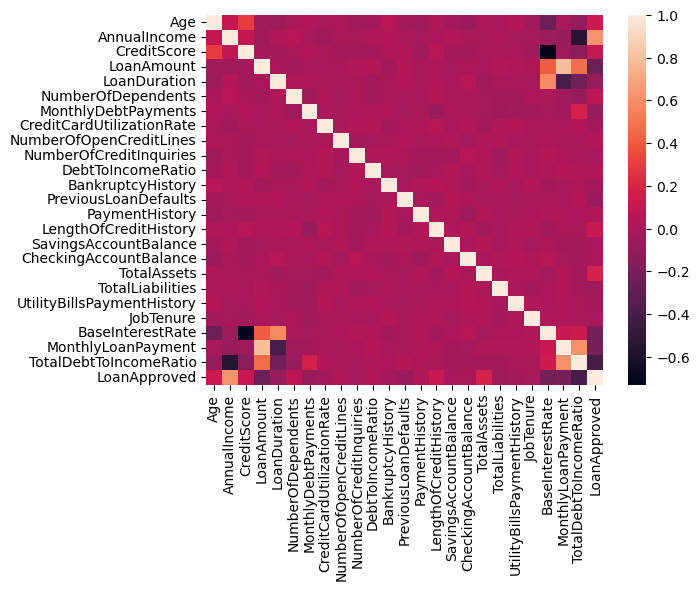

In [16]:
sns.heatmap(X_train.corr())
plt.show()

In [17]:
scaler = StandardScaler()

In [18]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Text(0.5, 1.0, 'X_train_scaled')

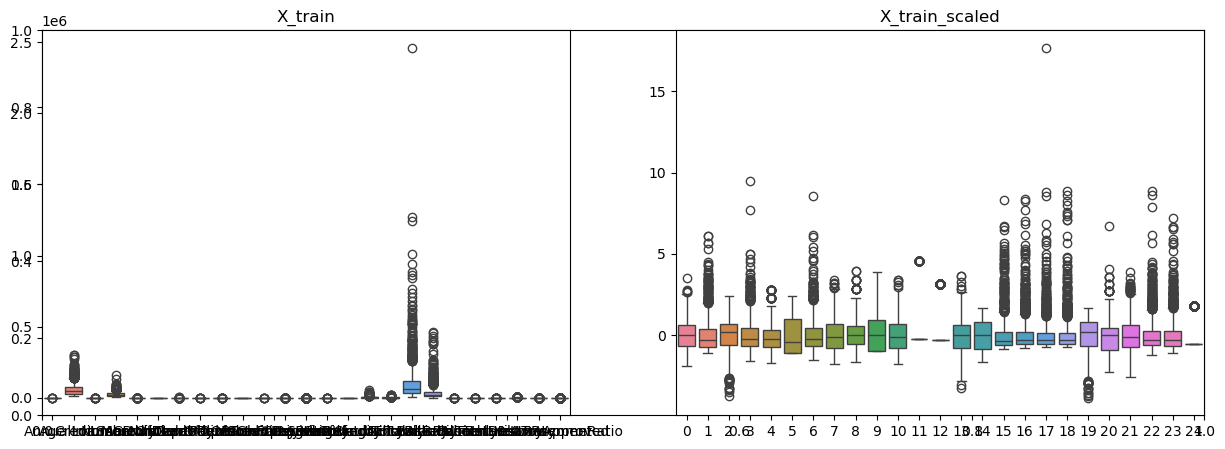

In [19]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title('X_train')
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title("X_train_scaled")

In [20]:
#Linear Regression

Mean Absolute Error: 1.8298315116428099
Mean Squared Error: 5.451698165527953
R2 Score: 0.9035937584200456


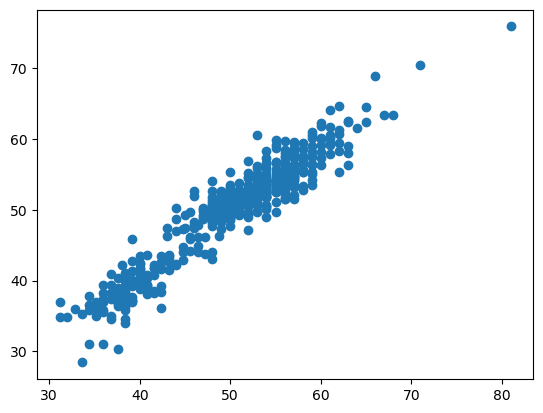

In [21]:
linear = LinearRegression()
linear.fit(X_train_scaled, y_train)
y_pred = linear.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print(f"Mean Absolute Error: {mae}\nMean Squared Error: {mse}\nR2 Score: {score}")
plt.scatter(y_test,y_pred)
plt.show()

In [22]:
#with lasso

Mean Absolute Error: 2.6840715093083807
Mean Squared Error: 11.78049752039331
R2 Score: 0.7916771150199753


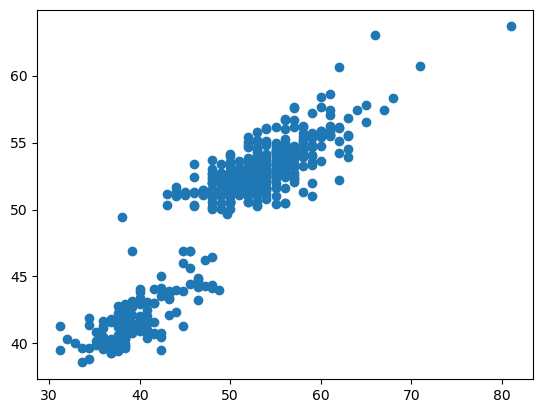

In [23]:
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print(f"Mean Absolute Error: {mae}\nMean Squared Error: {mse}\nR2 Score: {score}")
plt.scatter(y_test,y_pred)
plt.show()

In [24]:
# RİDGE

Mean Absolute Error: 1.8297825002804942
Mean Squared Error: 5.450870160871915
R2 Score: 0.9036084006130789


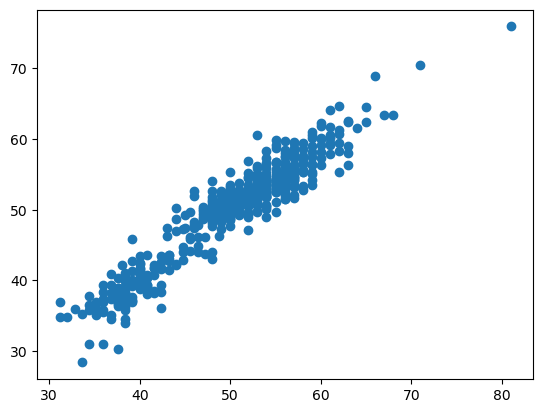

In [25]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print(f"Mean Absolute Error: {mae}\nMean Squared Error: {mse}\nR2 Score: {score}")
plt.scatter(y_test,y_pred)
plt.show()

In [26]:
# Elasticnet

Mean Absolute Error: 2.818583375666555
Mean Squared Error: 12.827305035070923
R2 Score: 0.7731656759997726


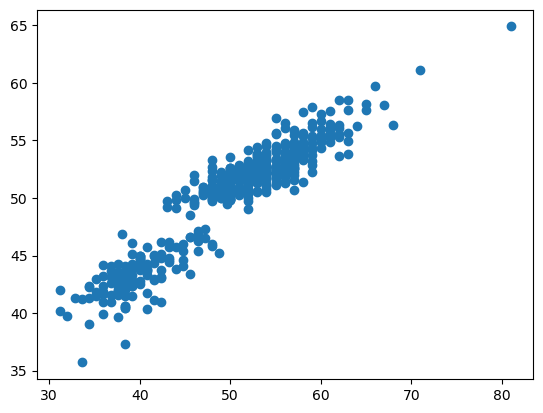

In [27]:
from sklearn.linear_model import ElasticNet
elasticnet = ElasticNet()
elasticnet.fit(X_train_scaled, y_train)
y_pred = elasticnet.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print(f"Mean Absolute Error: {mae}\nMean Squared Error: {mse}\nR2 Score: {score}")
plt.scatter(y_test,y_pred)
plt.show()

In [28]:
# with cross validation

Mean Absolute Error: 1.8260233446199545
Mean Squared Error: 5.376799606400756
R2 Score: 0.9049182427120896


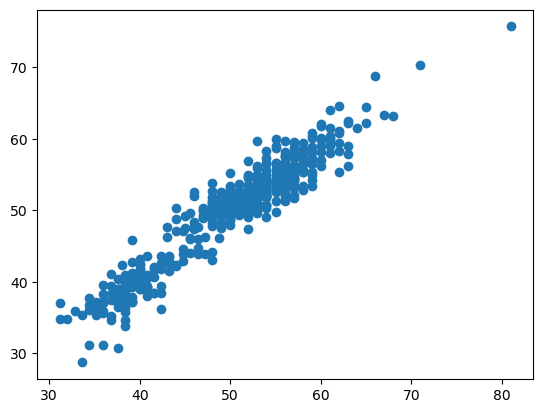

In [29]:
from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv=5)
lassocv.fit(X_train_scaled, y_train)
y_pred = lassocv.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print(f"Mean Absolute Error: {mae}\nMean Squared Error: {mse}\nR2 Score: {score}")
plt.scatter(y_test,y_pred)
plt.show()

Mean Absolute Error: 1.8295876963041005
Mean Squared Error: 5.445641818918776
R2 Score: 0.9037008570884913


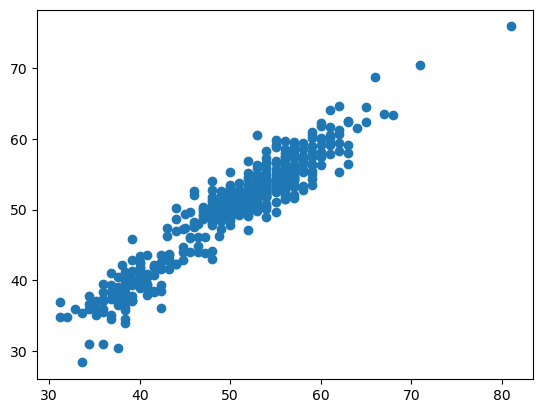

In [30]:
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV(cv=5)
ridgecv.fit(X_train_scaled, y_train)
y_pred = ridgecv.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print(f"Mean Absolute Error: {mae}\nMean Squared Error: {mse}\nR2 Score: {score}")
plt.scatter(y_test,y_pred)
plt.show()

Mean Absolute Error: 1.8292188319963478
Mean Squared Error: 5.404630339288822
R2 Score: 0.9044260921423608


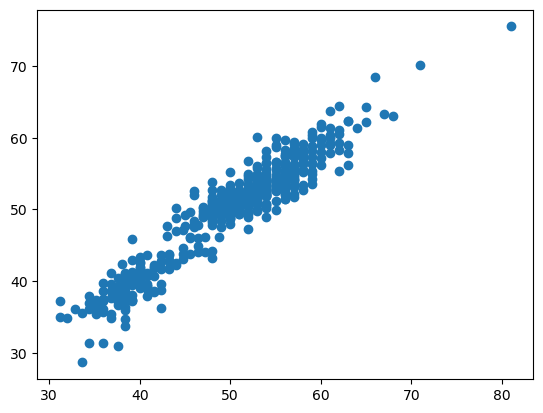

In [31]:
from sklearn.linear_model import ElasticNetCV
elasticcv= ElasticNetCV(cv=5)
elasticcv.fit(X_train_scaled, y_train)
y_pred = elasticcv.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print(f"Mean Absolute Error: {mae}\nMean Squared Error: {mse}\nR2 Score: {score}")
plt.scatter(y_test,y_pred)
plt.show()